First cluster


In [78]:
%load_ext autoreload
%matplotlib inline

/Users/larrywu/Documents/electron_optics
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [79]:
%autoreload 2
import sys
import os

current_dir = os.getcwd()

if current_dir not in sys.path:
    sys.path.insert(0, current_dir)
from model import *
from load_data import *
from utils import *

In [80]:
EPOCH=150

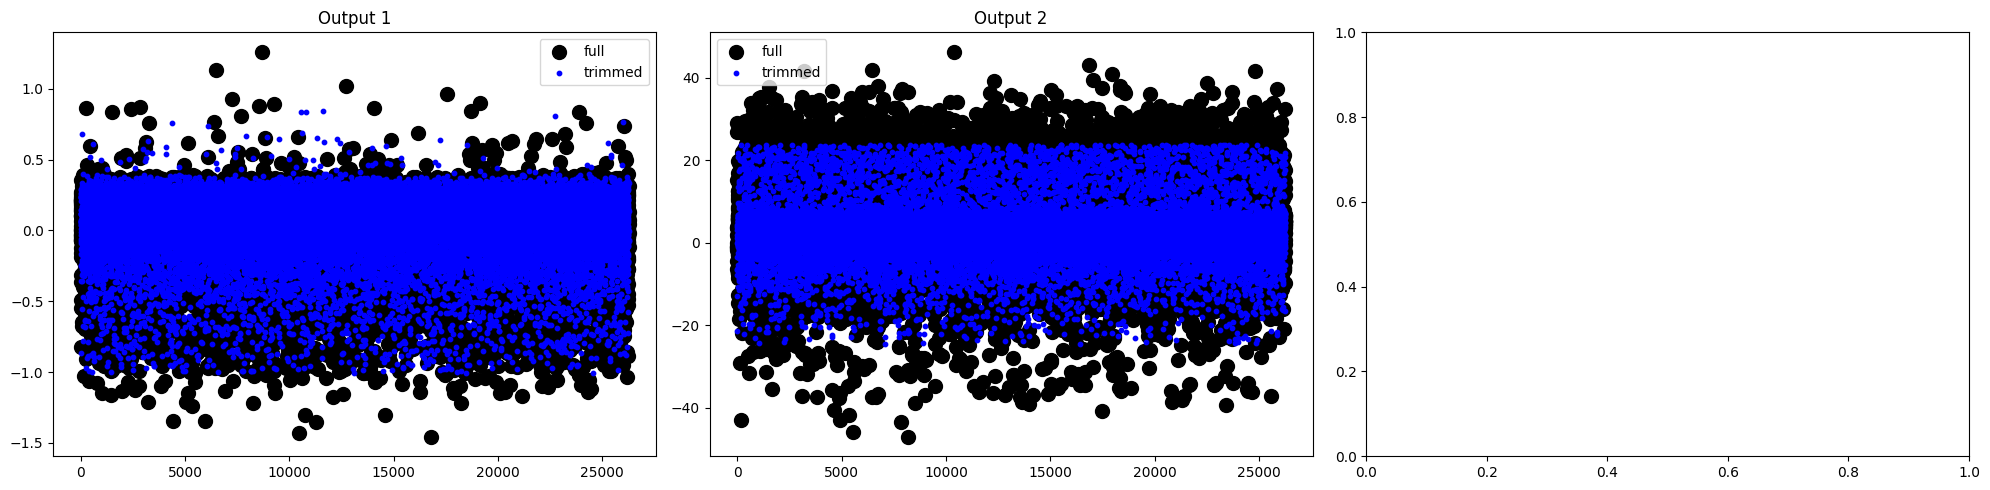

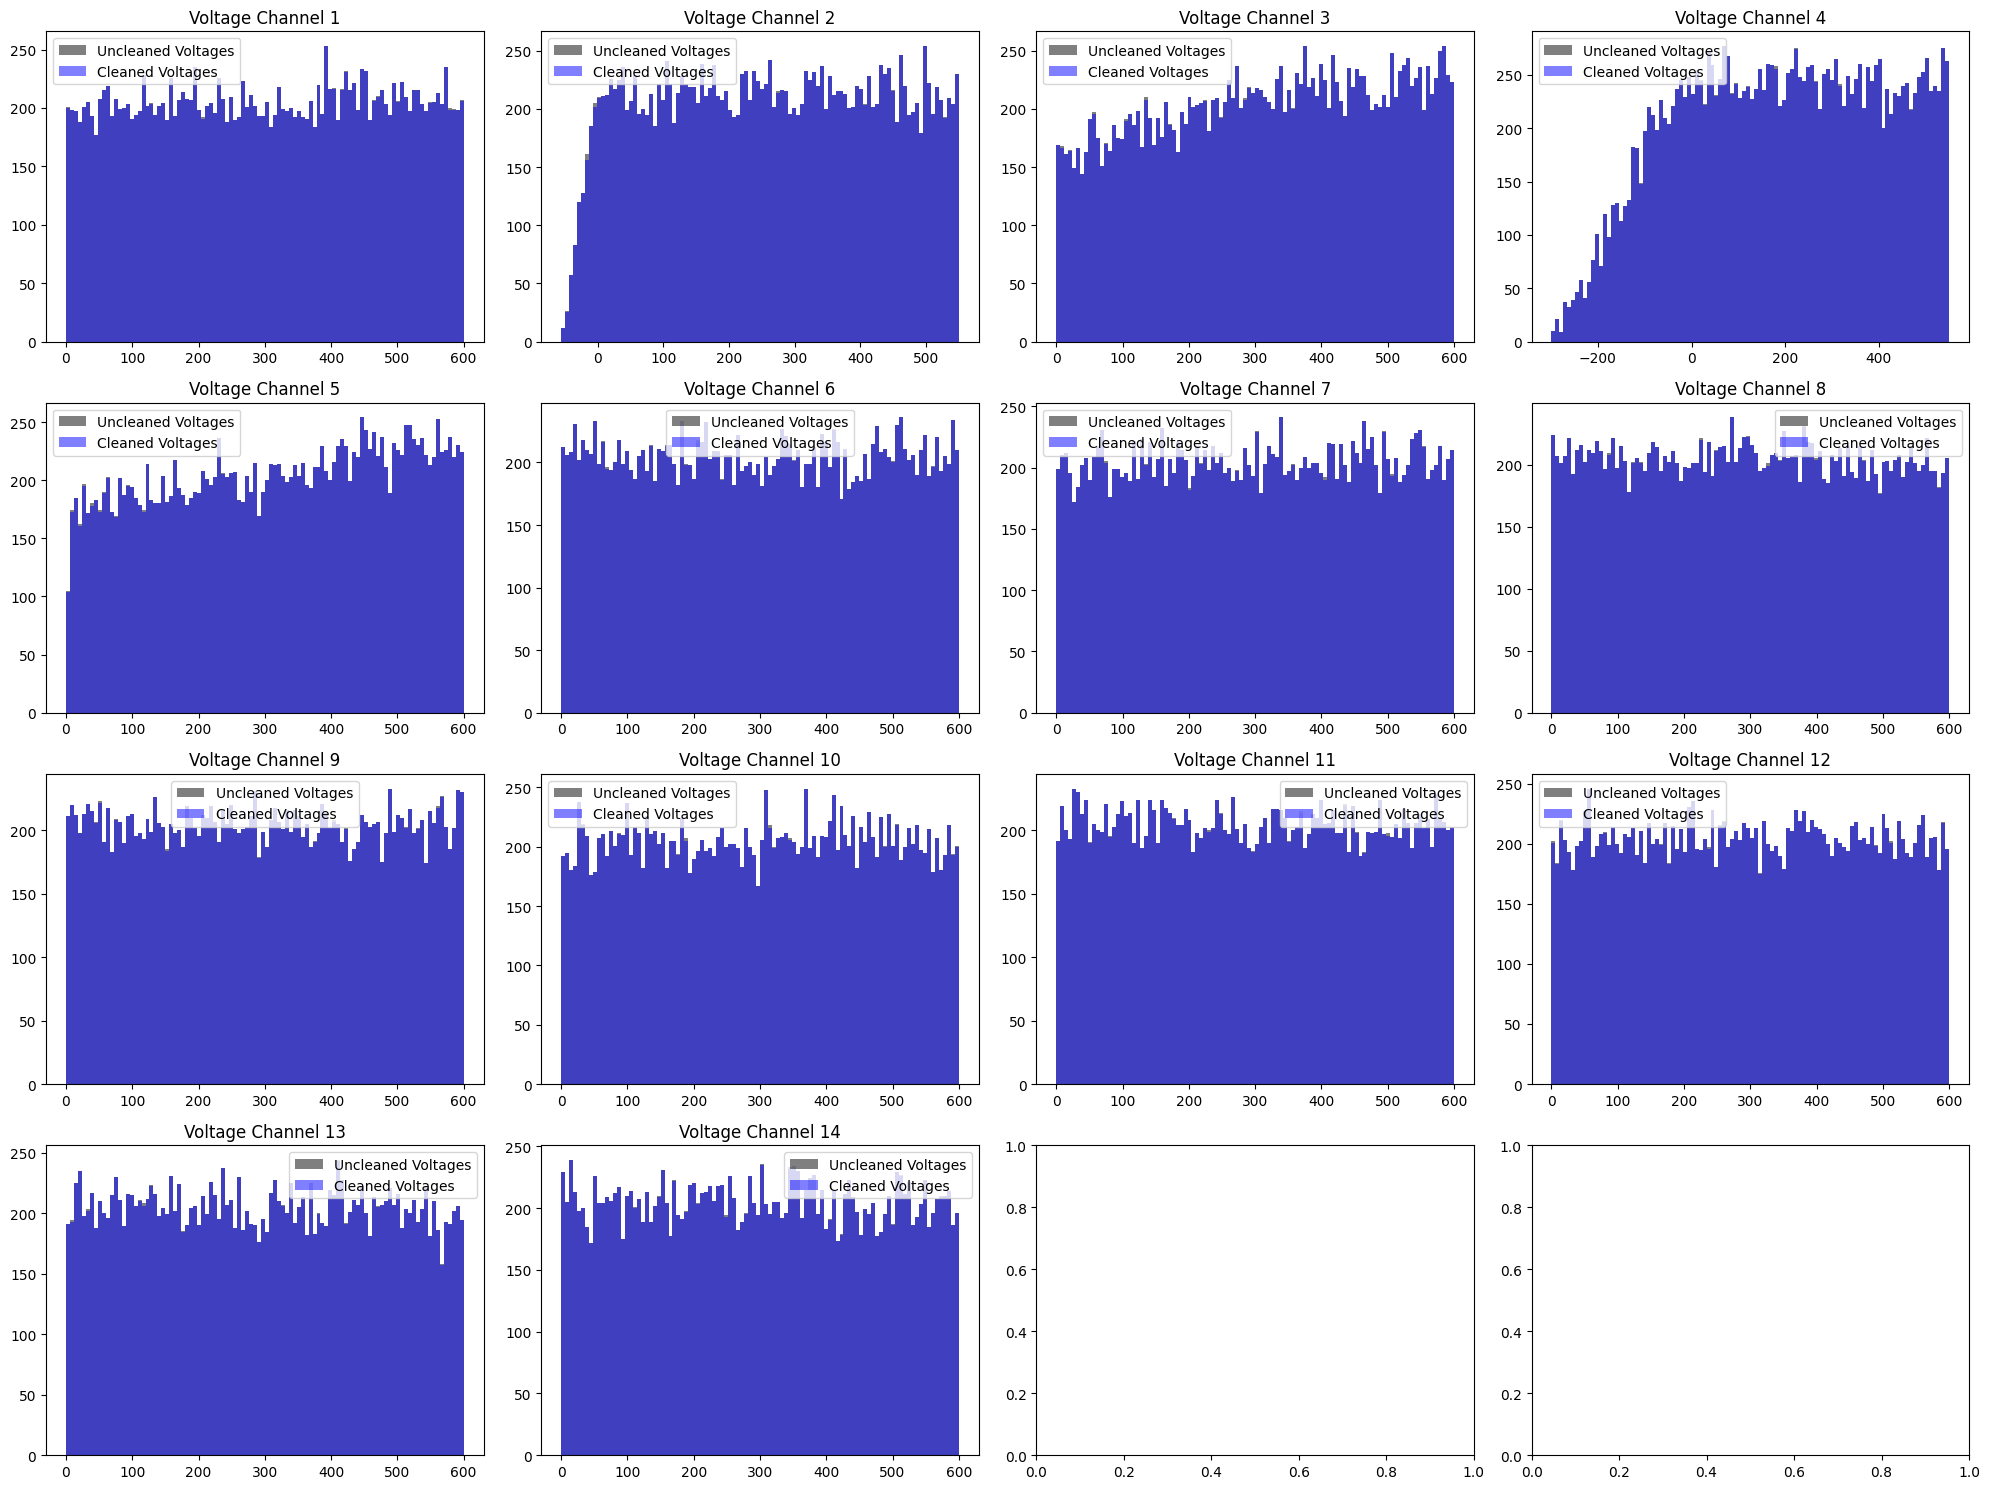

99.9% of data retained after cleaning


In [81]:
threshold = 4
trim_mode = "iqr"
_, ax, _, _, _, _ = trim_scatter(
    [
        "test_model_data.csv",
        "parallel_test_model_data.csv",
        "outlier_target_model_data.csv",
    ],
    output_values_start=14,
    output_values_end=15,
    trim_mode=trim_mode,
    trim_threshold=threshold,
    subplot_shape=(1, 3),
    figsize=(20, 5),
)
# ax[0].set_xlim(0, 100)
# ax[0].set_ylim(-5, 5)
_, _, _, _, fig, ax = trim_hist(
    [
        "test_model_data.csv",
        "parallel_test_model_data.csv",
        # "outlier_target_model_data.csv",
    ],
    output_values_start=14,
    output_values_end=15,
    trim_mode=trim_mode,
    trim_threshold=threshold,
    subplot_shape=(4, 4),
)

Using device: mps
Training model...
Epoch 0: Train Loss = 0.814586, Val Loss = 0.637545
Epoch 100: Train Loss = 0.261316, Val Loss = 0.280522
Training completed. Best validation loss: 0.089763


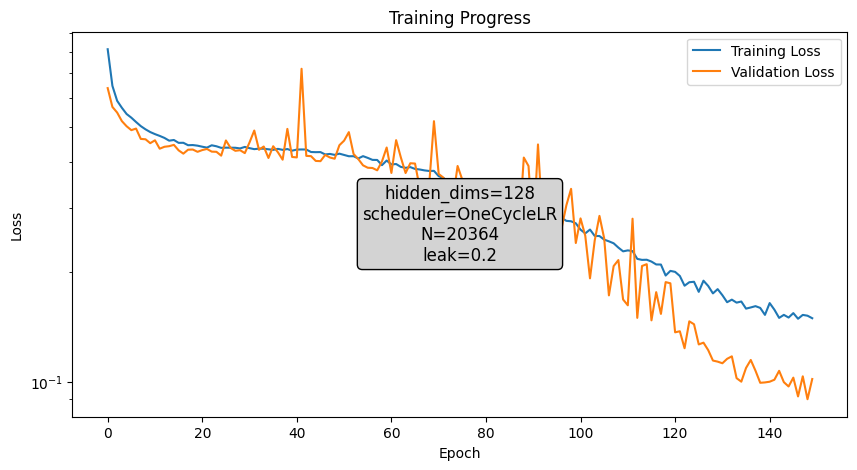

In [82]:
n_voltages = 14  # Number of voltage parameters
n_output_values = 2  # Number of output values (e.g., magnification, aberration, etc.)
raw_voltages, raw_outputs = load_data(
    [
        "parallel_test_model_data.csv",
        "test_model_data.csv",
        "outlier_target_model_data.csv",
    ],
    output_values_start=14,
    output_values_end=15,
)
voltages, outputs, outlier_voltages, outlier_outputs = trim_outliers(
    raw_voltages,
    raw_outputs,
    trim_threshold=threshold,
    trim_mode=trim_mode,
)
# Create and train model
predictor1 = ElectronOpticsPredictor(
    input_dim=n_voltages, output_dim=n_output_values, model=ResidualMLP, leak=0.2, hidden_dims=128
)
print("Training model...")
predictor1.train(
    voltages,
    outputs,
    epochs=EPOCH,
    verbose=True,
    checkpoint_name="best_model1.pt",
)


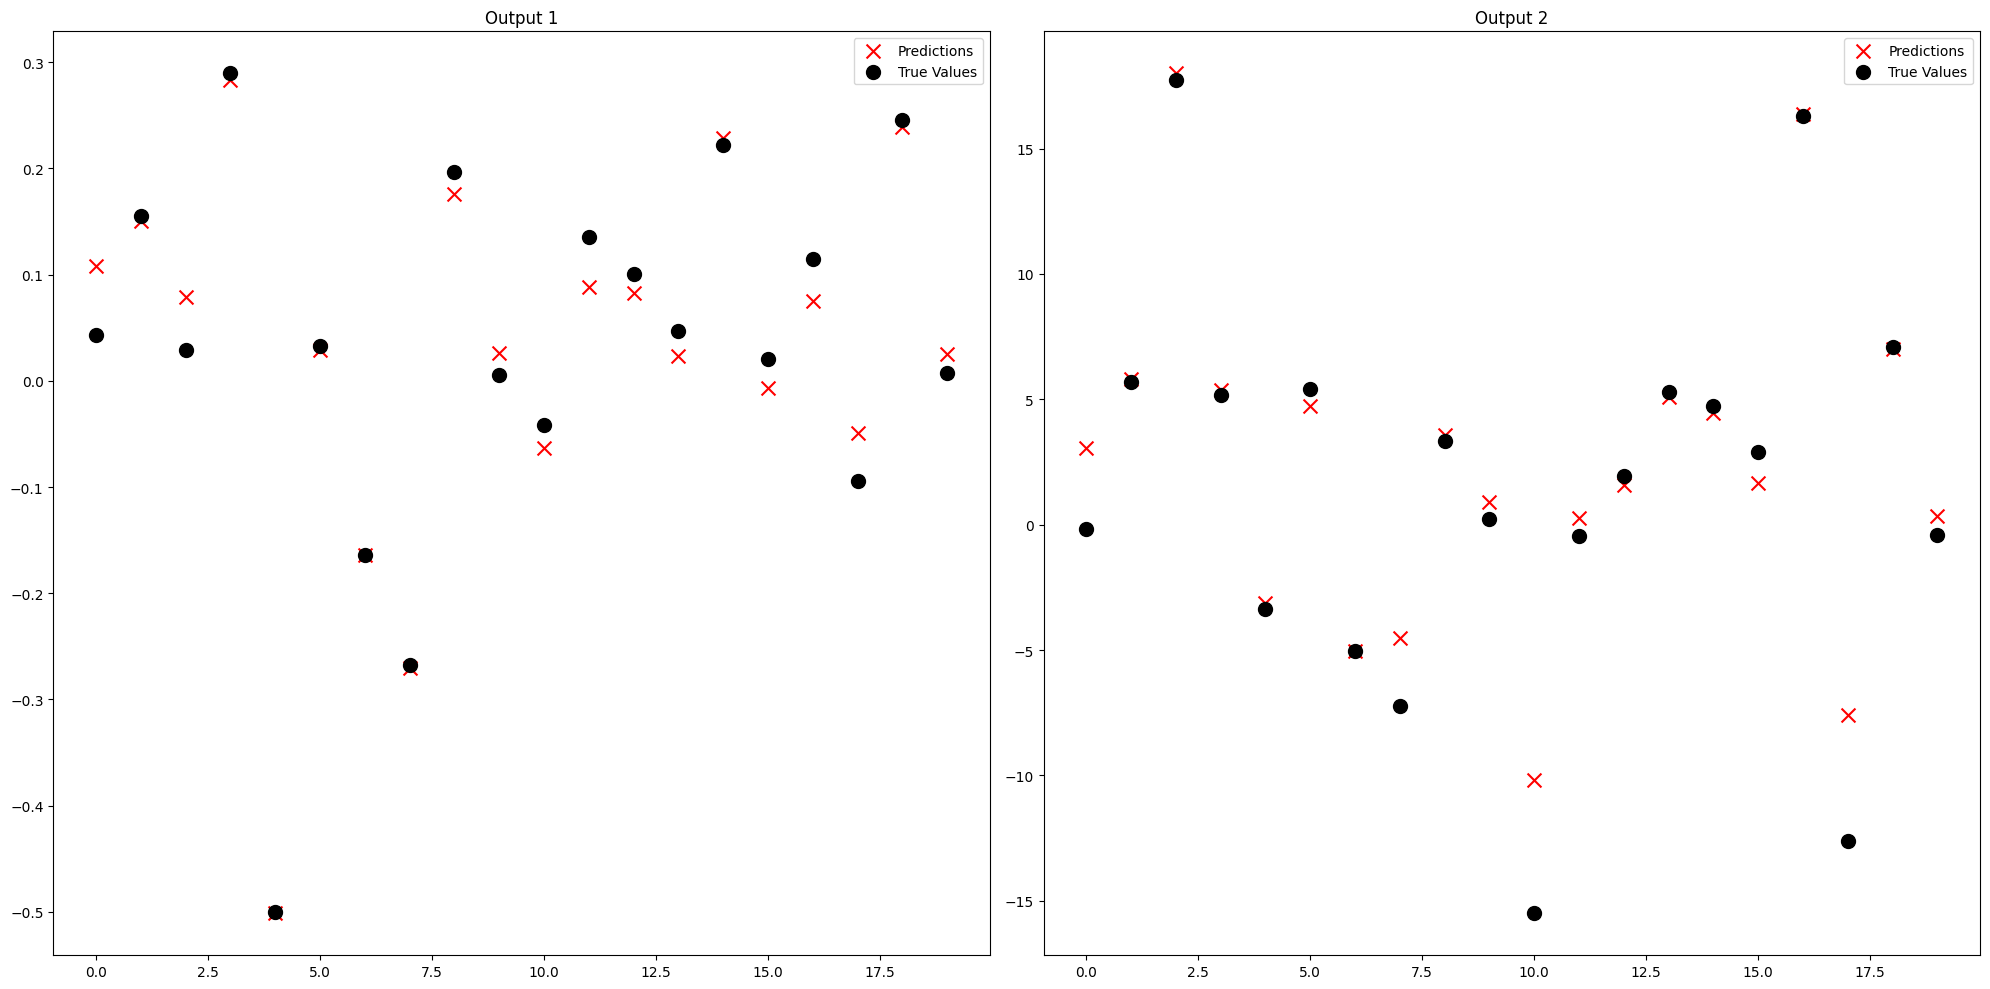

In [129]:
predictor1.model.to(device='mps')
_, _, all_predictions, all_true_values = plot_inference_comparison(
    predictor1, n_samples=20, subplot_shape=(1, 2)
)

cluster 2

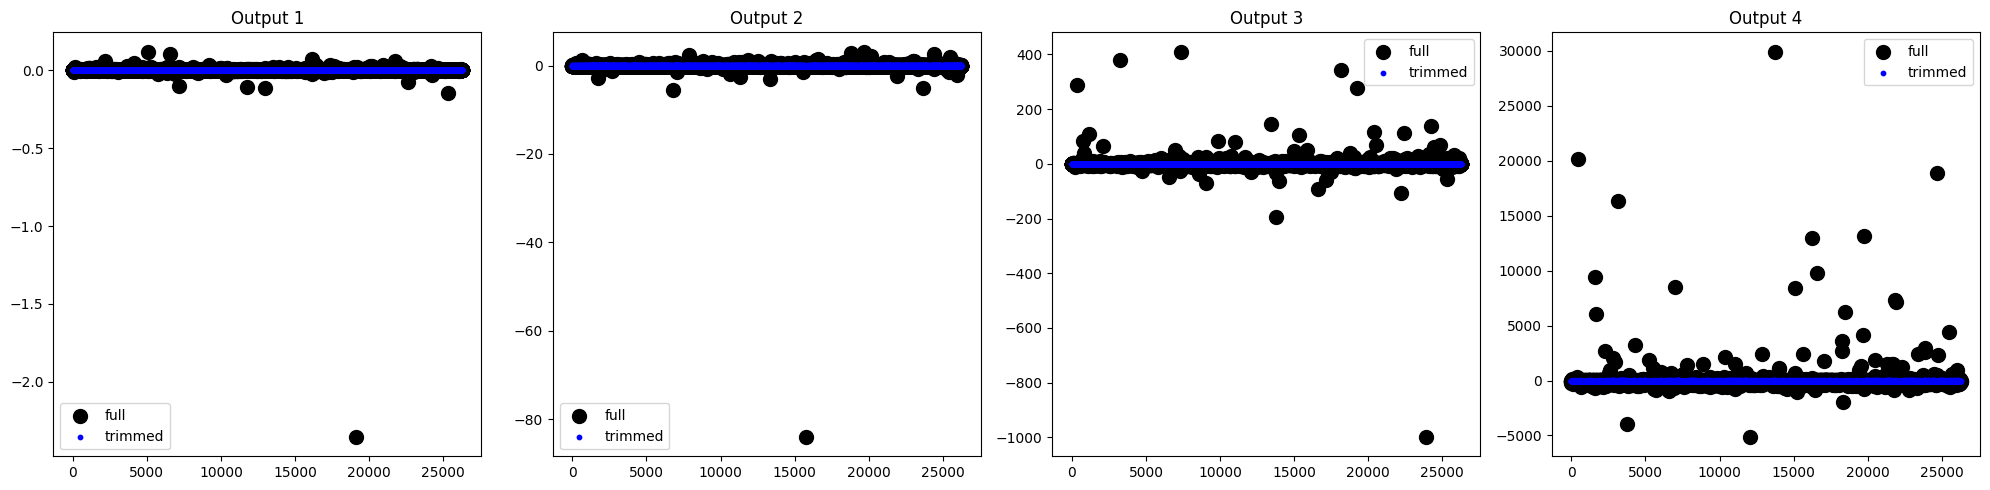

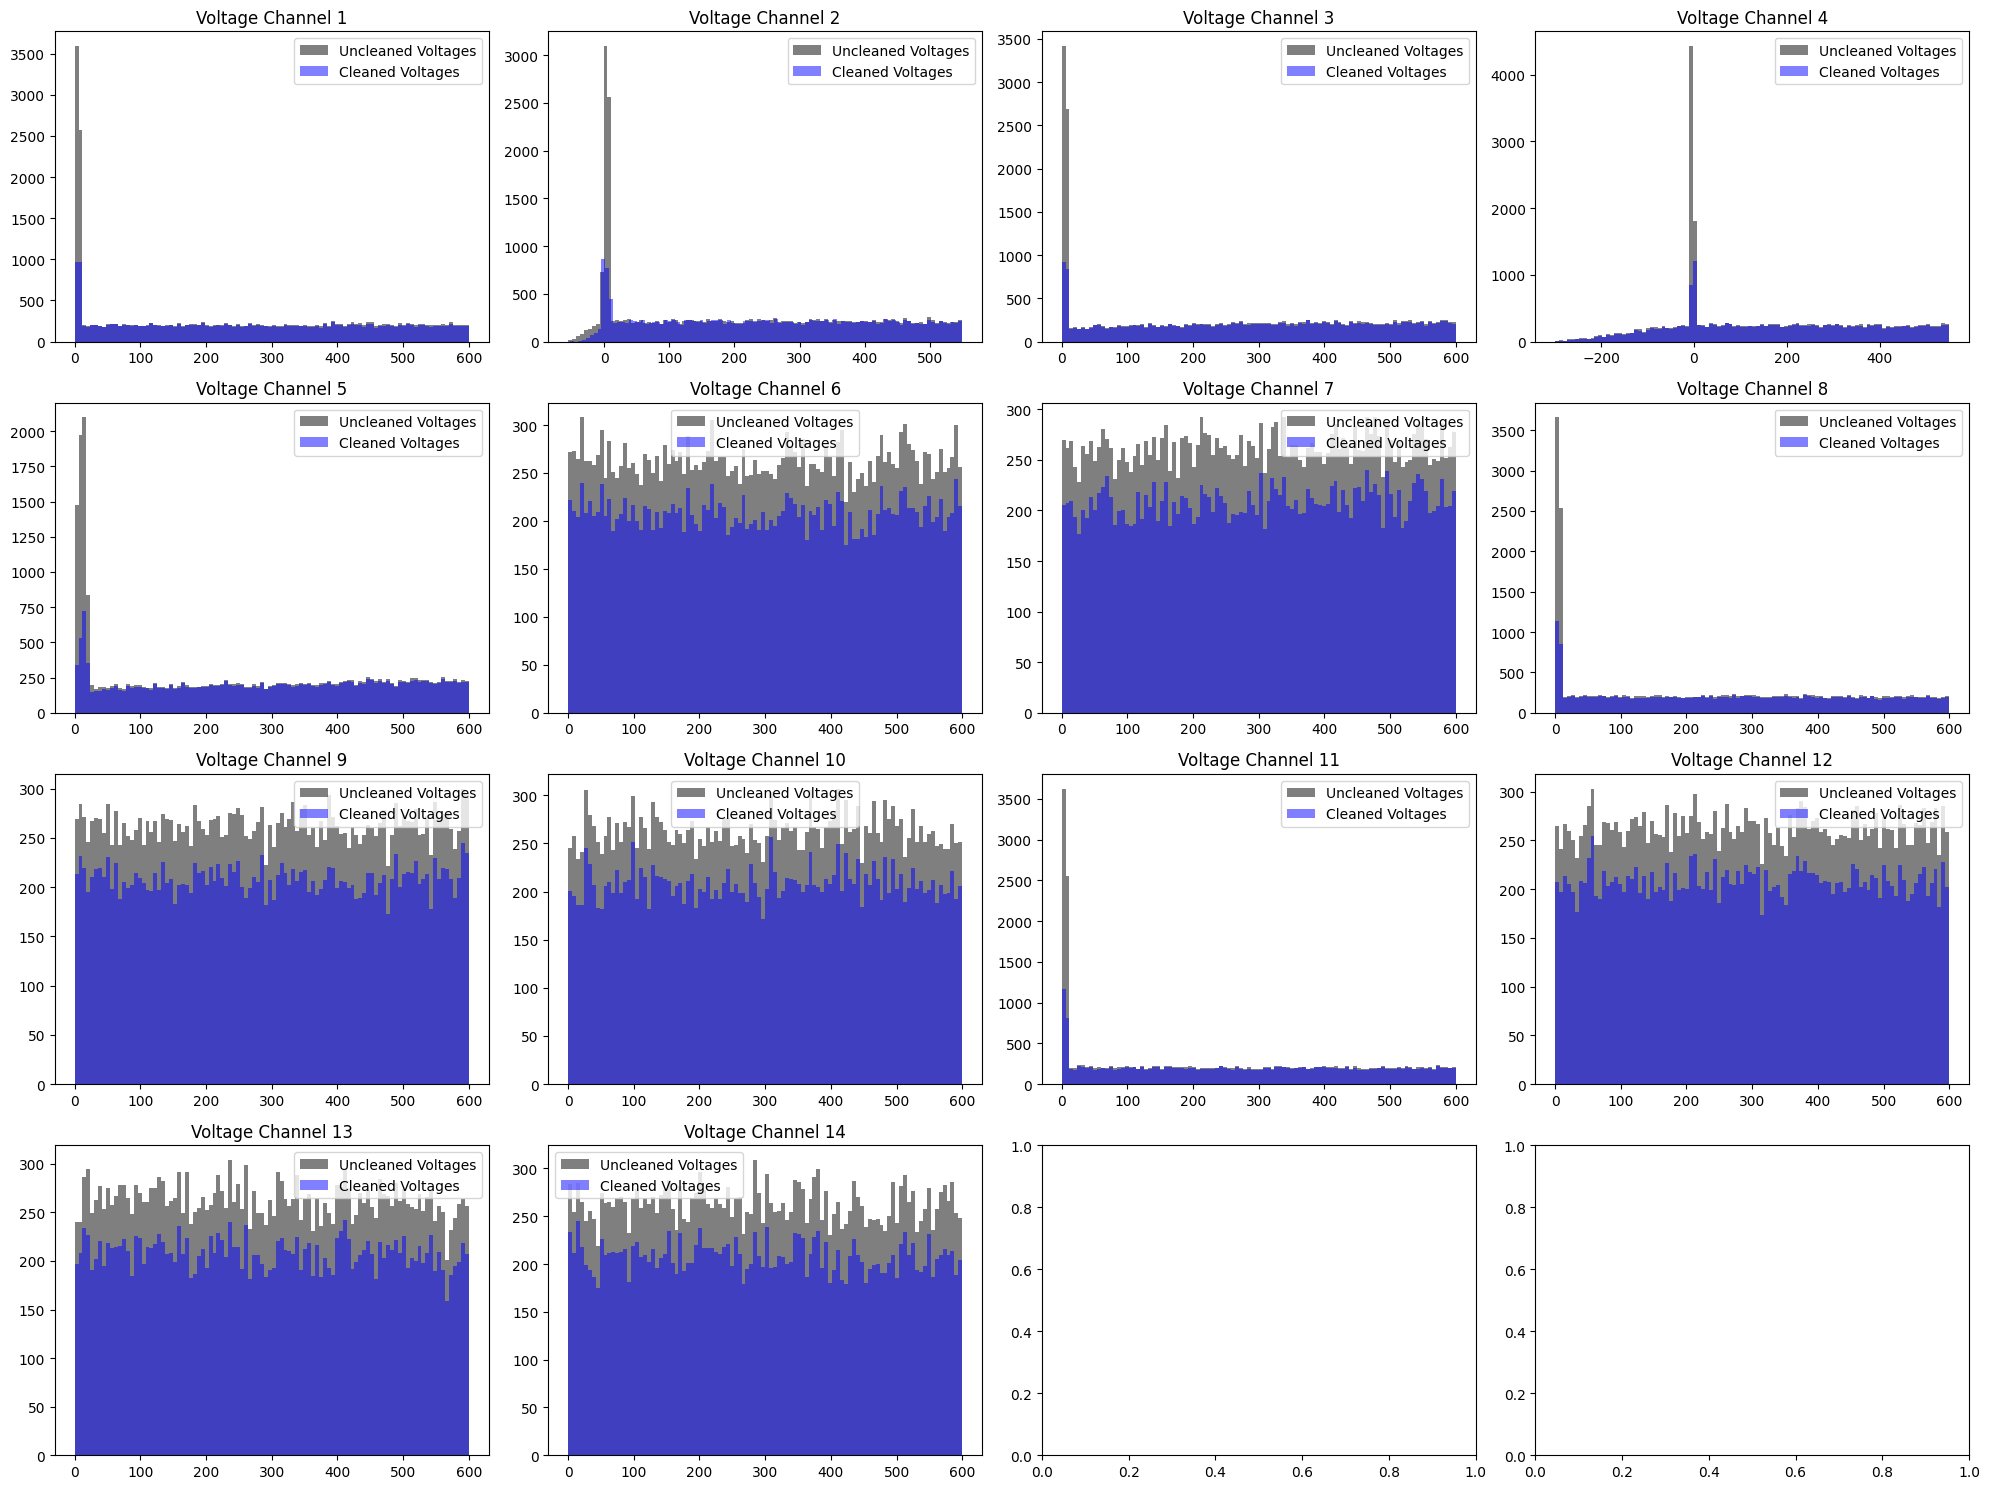

79.3% of data retained after cleaning


In [84]:
threshold = [10, 10, 10, 10]  # Thresholds for each output value
trim_mode = "iqr"
_, ax, _, _, _, _ = trim_scatter(
    [
        "test_model_data.csv",
        "parallel_test_model_data.csv",
        "outlier_target_model_data.csv",
    ],
    output_values_start=16,
    output_values_end=19,
    trim_threshold=threshold,
    trim_mode=trim_mode,
    subplot_shape=(1, 4),
    figsize=(20, 5),
)
# ax[0].set_xlim(0, 100)

ax[0].set_ylim(-0.0025, 0.0025)
ax[1].set_ylim(-0.1, 0.1)
ax[2].set_ylim(-2, 1)
ax[3].set_ylim(-10, 10)

_, _, _, _, fig, ax = trim_hist(
    [
        "test_model_data.csv",
        "parallel_test_model_data.csv",
        "outlier_target_model_data.csv",
    ],
    output_values_start=16,
    output_values_end=19,
    trim_threshold=threshold,
    trim_mode=trim_mode,
    subplot_shape=(4, 4),
)

Using device: mps
Training model...
Epoch 0: Train Loss = 0.807283, Val Loss = 0.651364
Epoch 100: Train Loss = 0.357769, Val Loss = 0.329685
Training completed. Best validation loss: 0.275972


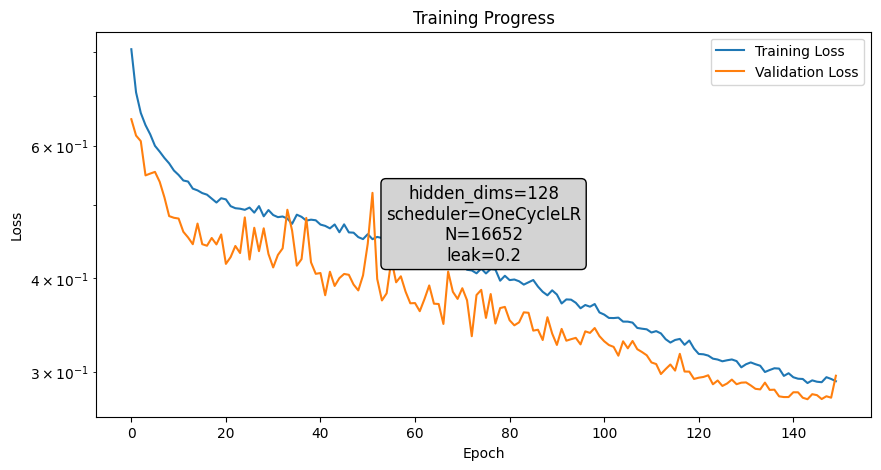

In [85]:
n_voltages = 14  # Number of voltage parameters
n_output_values = 4  # Number of output values (e.g., magnification, aberration, etc.)
raw_voltages, raw_output_values = load_data(
    [
        "parallel_test_model_data.csv",
        "test_model_data.csv",
        "outlier_target_model_data.csv",
    ],
    output_values_start=16,
    output_values_end=19,
)
voltages, outputs, outlier_voltages, outlier_outputs = trim_outliers(
    raw_voltages,
    raw_output_values,
    trim_threshold=threshold,
    trim_mode=trim_mode,
)
# Create and train model
predictor2 = ElectronOpticsPredictor(
    input_dim=n_voltages, output_dim=n_output_values, model=ResidualMLP, leak=0.2, hidden_dims=128
)
print("Training model...")
predictor2.train(
    voltages,
    outputs,
    epochs=EPOCH,
    verbose=True,
    checkpoint_name="best_model2.pt",
)


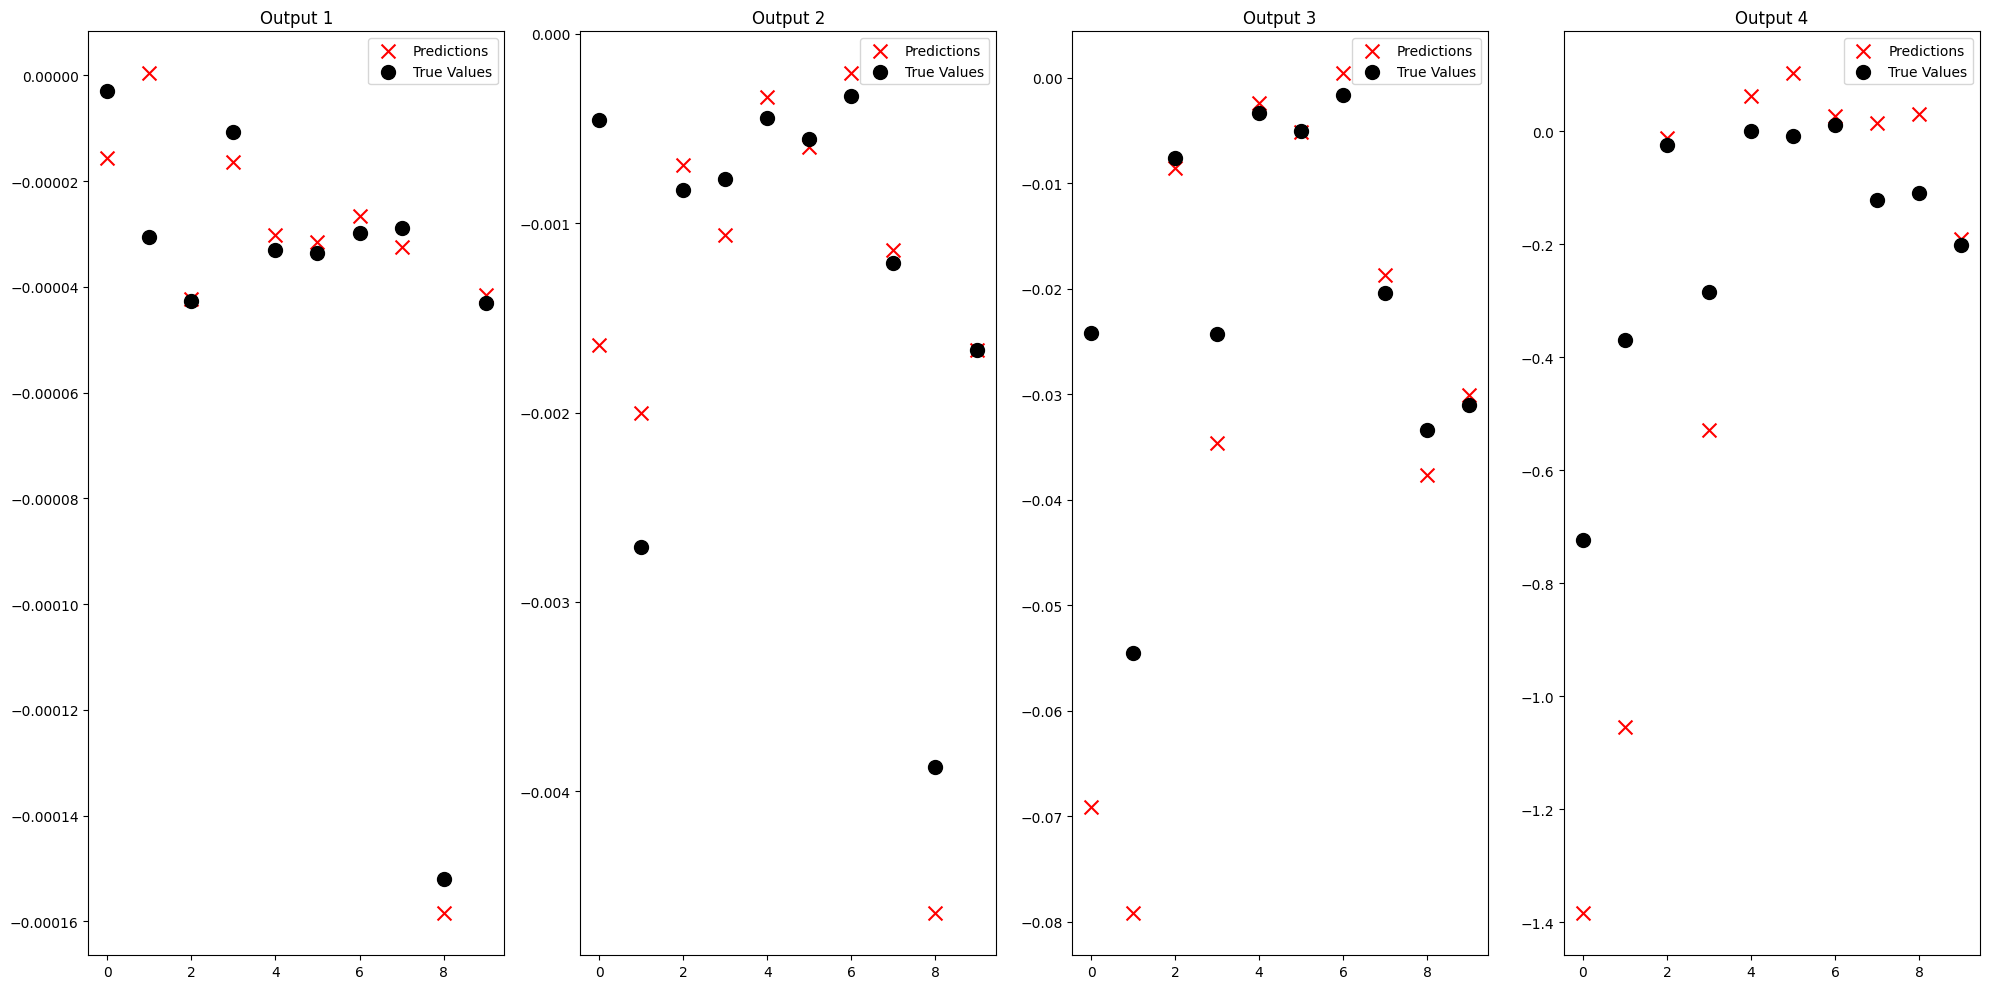

In [ ]:
predictor2.model.to(device='mps')
_, _, all_predictions, all_true_values = plot_inference_comparison(
    predictor2, n_samples=10, subplot_shape=(1, 4)
)

Cluster 3

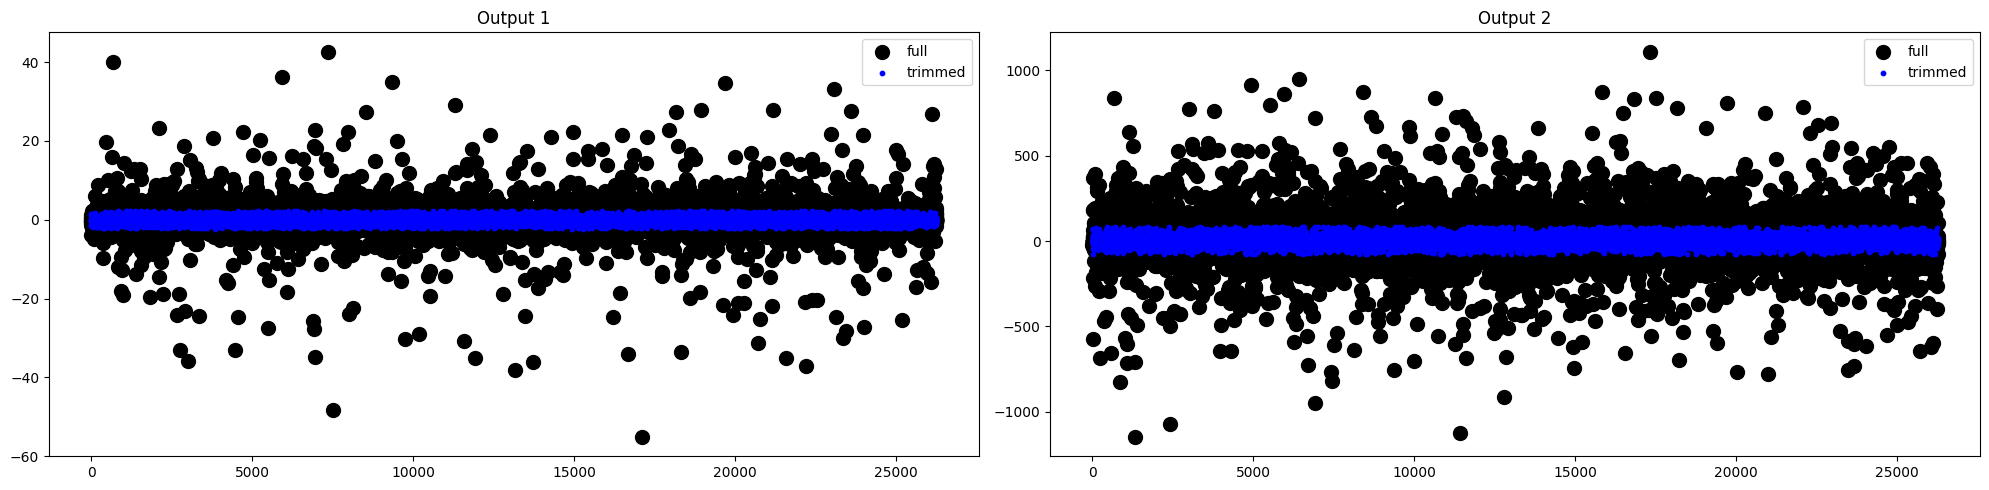

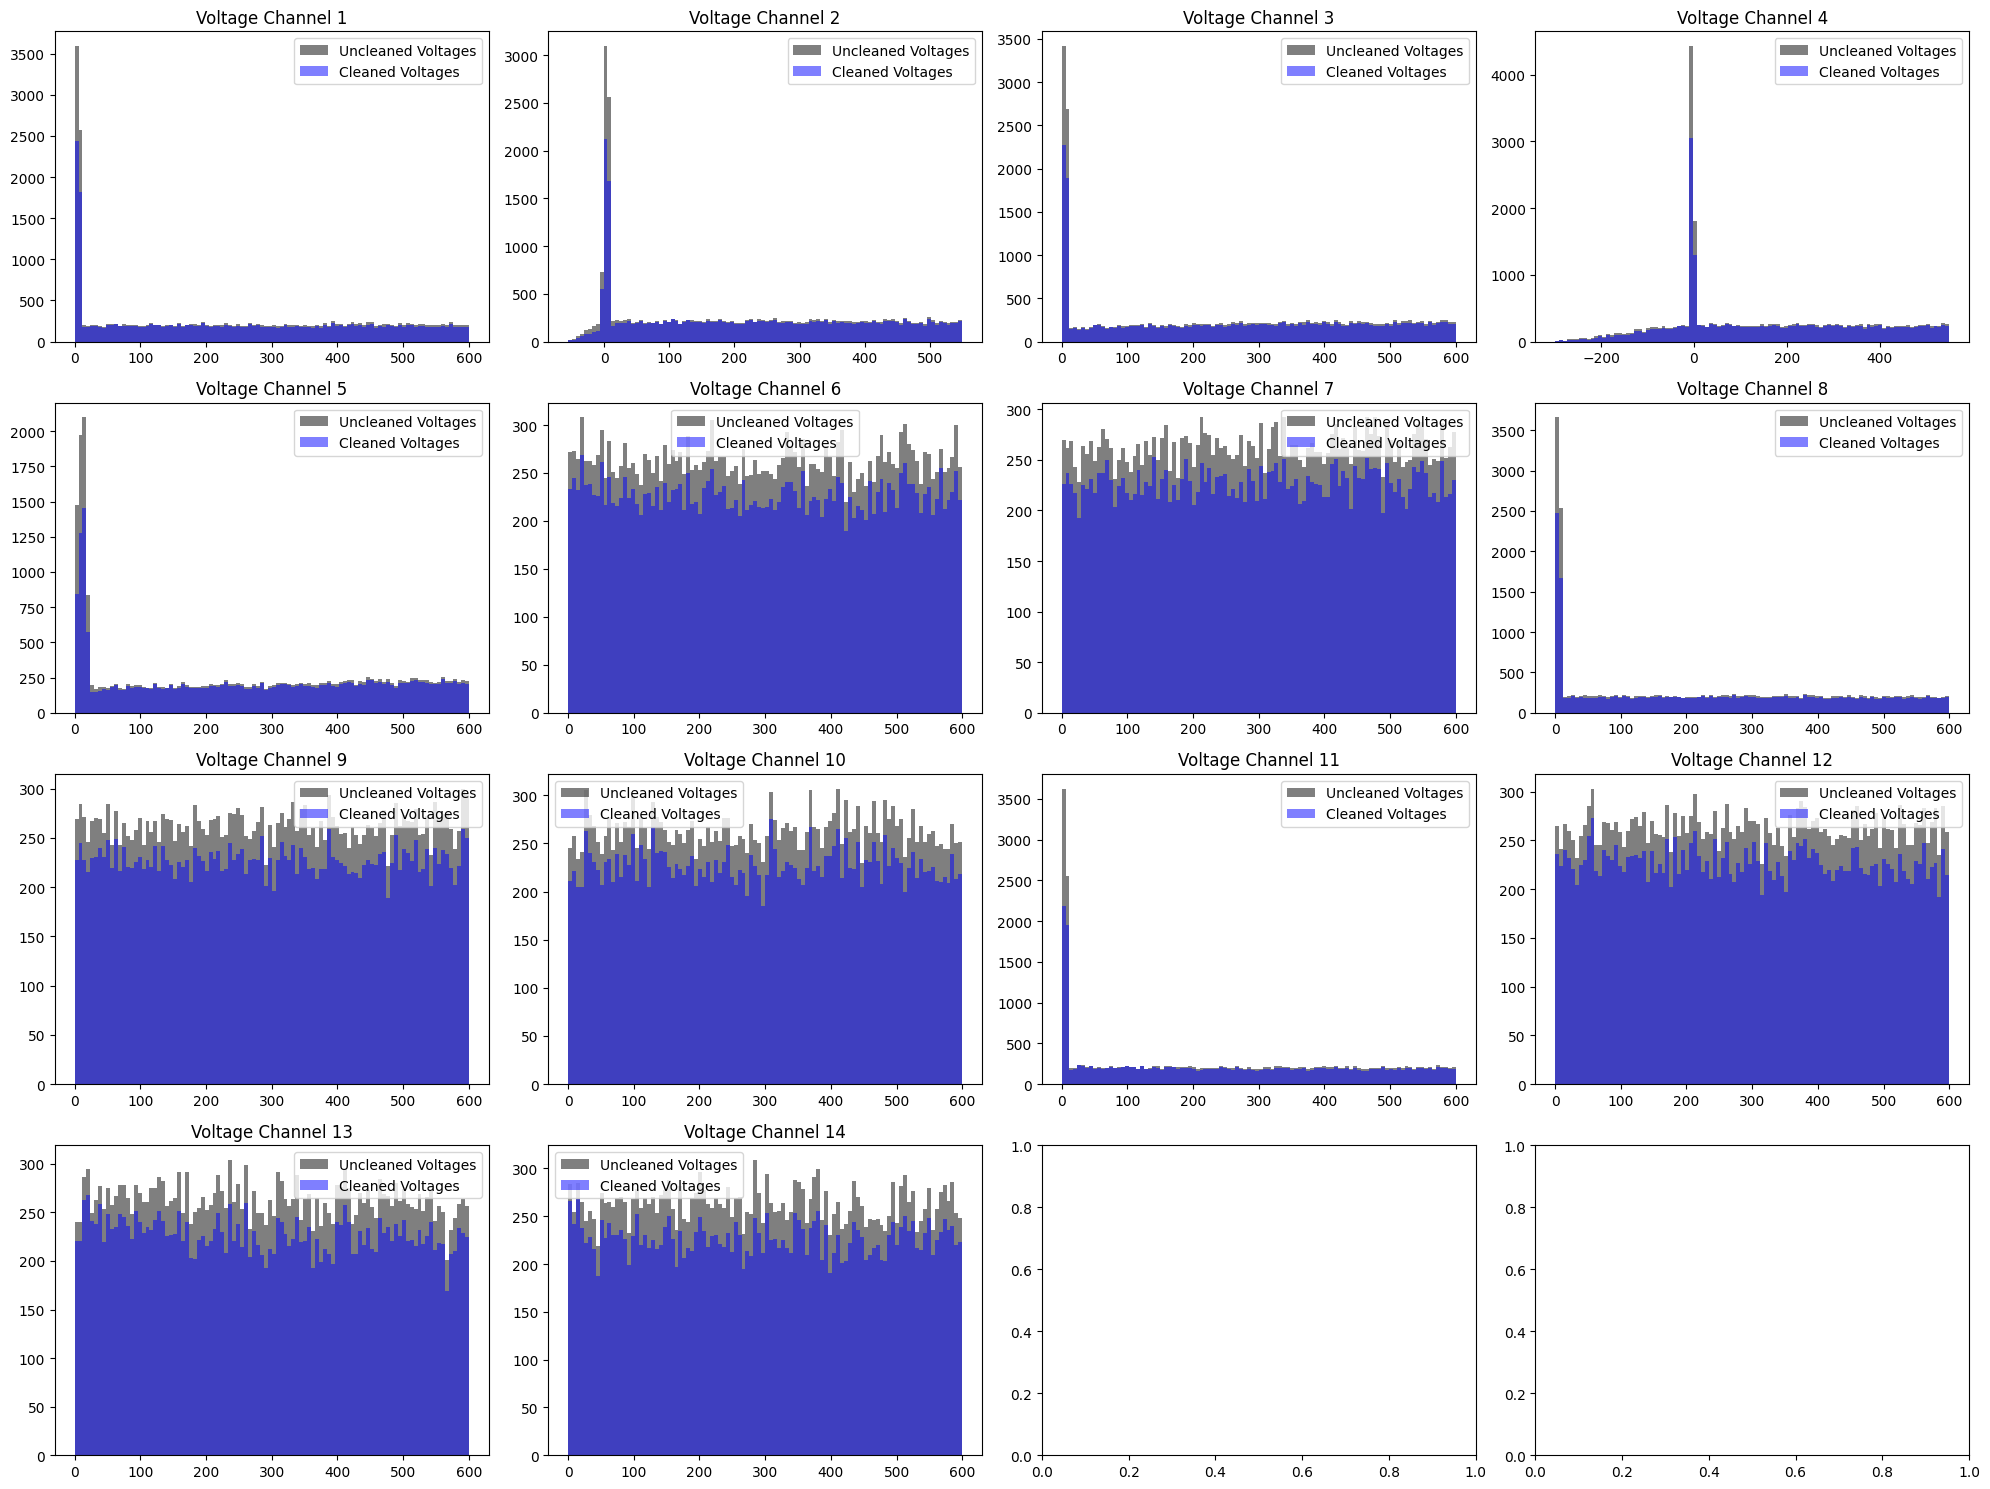

86.4% of data retained after cleaning


In [87]:
threshold = 1
_, ax, _, _, _, _ = trim_scatter(
    [
        "test_model_data.csv",
        "parallel_test_model_data.csv",
        "outlier_target_model_data.csv",
    ],
    output_values_start=20,
    output_values_end=21,
    trim_threshold=threshold,
    subplot_shape=(1, 2),
    figsize=(20, 5),
)
# ax[0].set_xlim(0, 100)


_, _, _, _, fig, ax = trim_hist(
    [
        "test_model_data.csv",
        "parallel_test_model_data.csv",
        "outlier_target_model_data.csv",
    ],
    output_values_start=20,
    output_values_end=21,
    trim_threshold=threshold,
    subplot_shape=(4, 4),
)

Using device: mps
Training model...
Epoch 0: Train Loss = 1.093976, Val Loss = 0.928351
Epoch 100: Train Loss = 0.446819, Val Loss = 0.433112
Training completed. Best validation loss: 0.381999


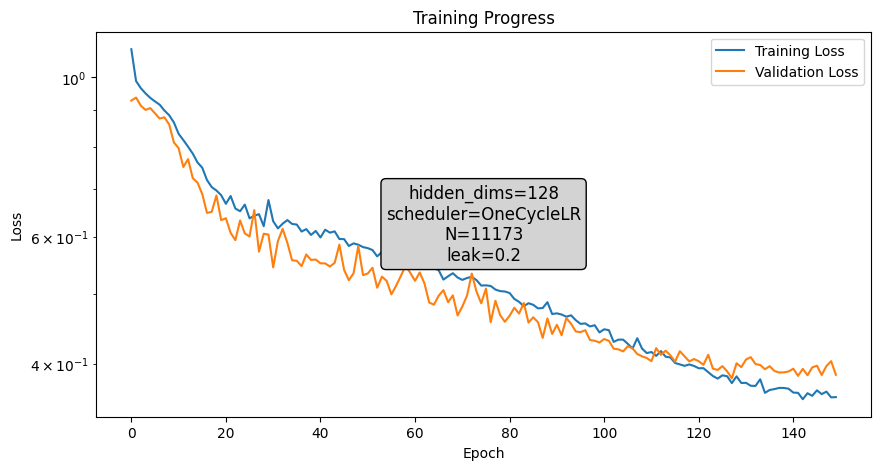

In [88]:
n_voltages = 14  # Number of voltage parameters


n_output_values = 2  # Number of output values (e.g., magnification, aberration, etc.)


raw_voltages, raw_output_values = load_data(
    [
        "parallel_test_model_data.csv",
        "test_model_data.csv",
        "outlier_target_model_data.csv",
    ],
    output_values_start=20,
    output_values_end=21,
)
voltages, outputs, outlier_voltages, outlier_outputs = trim_outliers(
    raw_voltages,
    raw_output_values,
    trim_threshold=threshold,
    trim_mode=trim_mode,
)


# Create and train model


predictor3 = ElectronOpticsPredictor(
    input_dim=n_voltages, output_dim=n_output_values, model=ResidualMLP, leak=0.2 ,num_blocks=3,hidden_dims=128
)


print("Training model...")


predictor3.train(
    voltages,
    outputs,
    epochs=EPOCH,
    verbose=True,
    checkpoint_name="best_model3.pt",
)


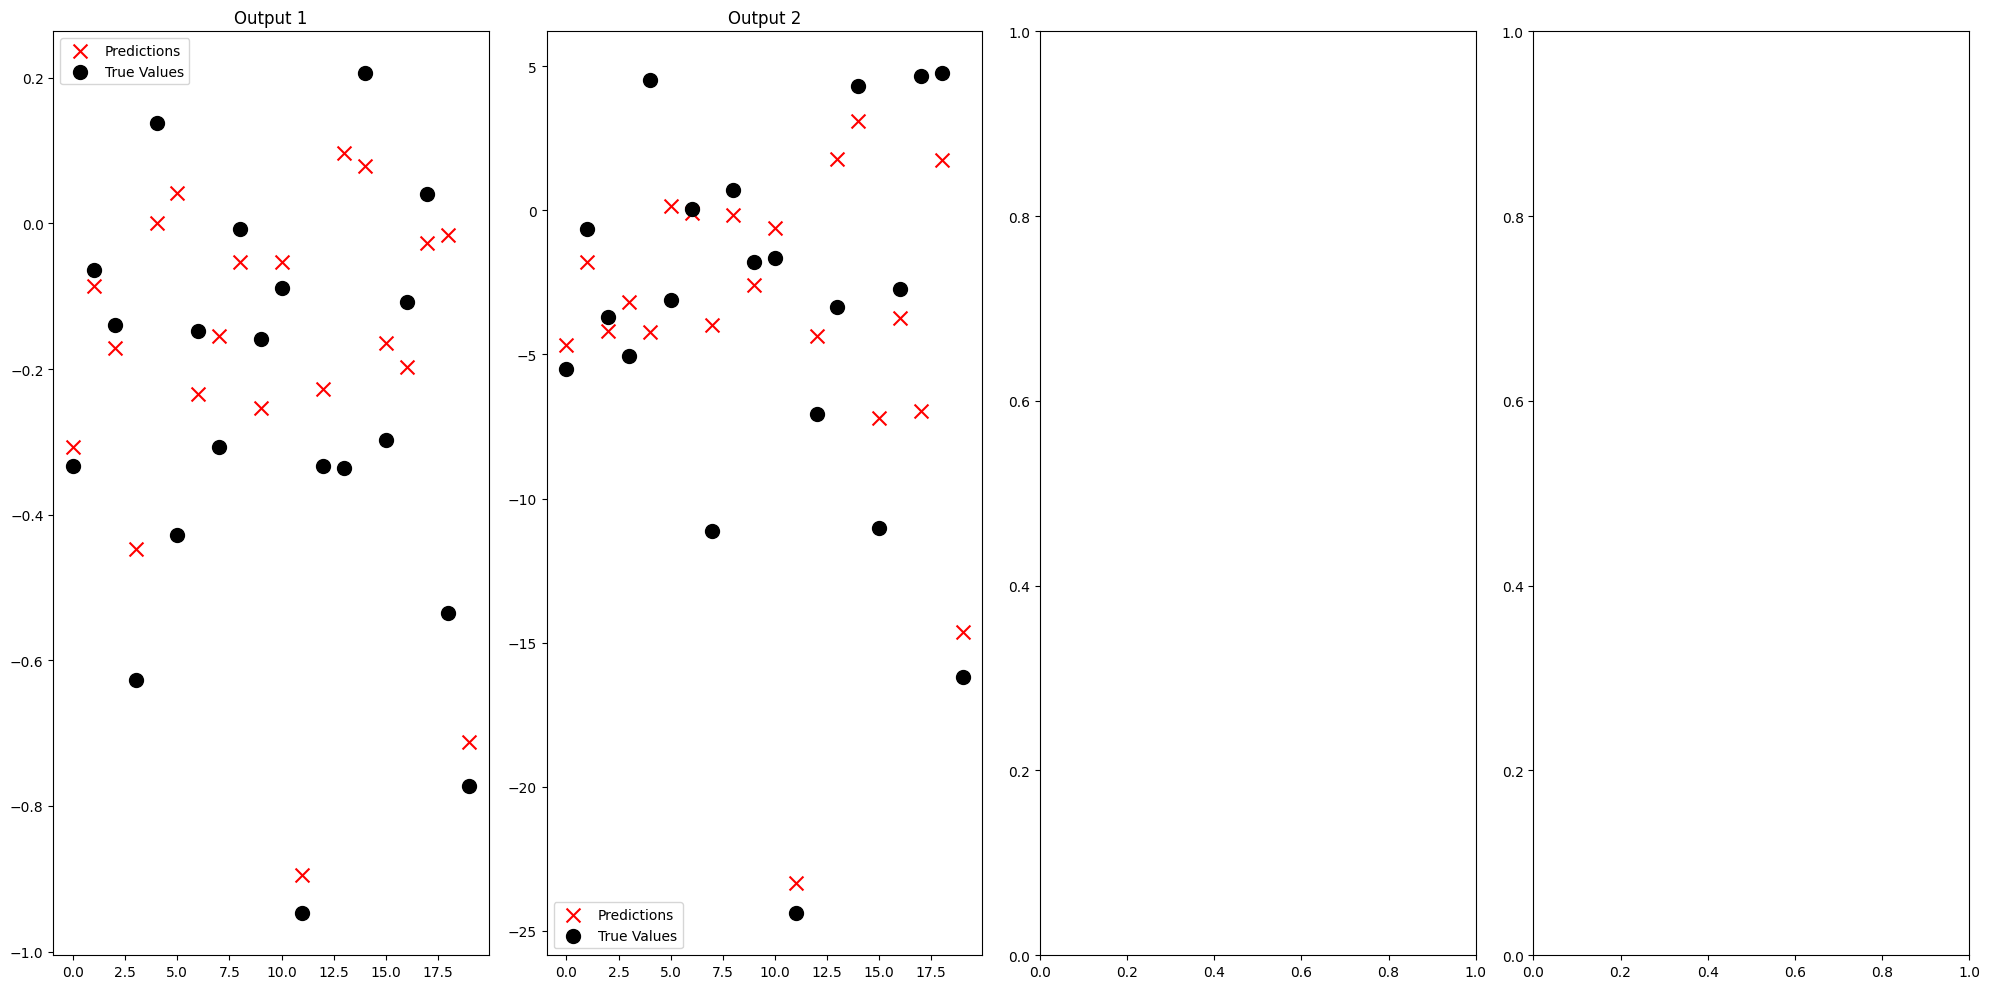

In [108]:
predictor3.model.to(device='mps')
_, _, all_predictions, all_true_values = plot_inference_comparison(
    predictor3, n_samples=20, subplot_shape=(1, 4)
)

Cluster 4

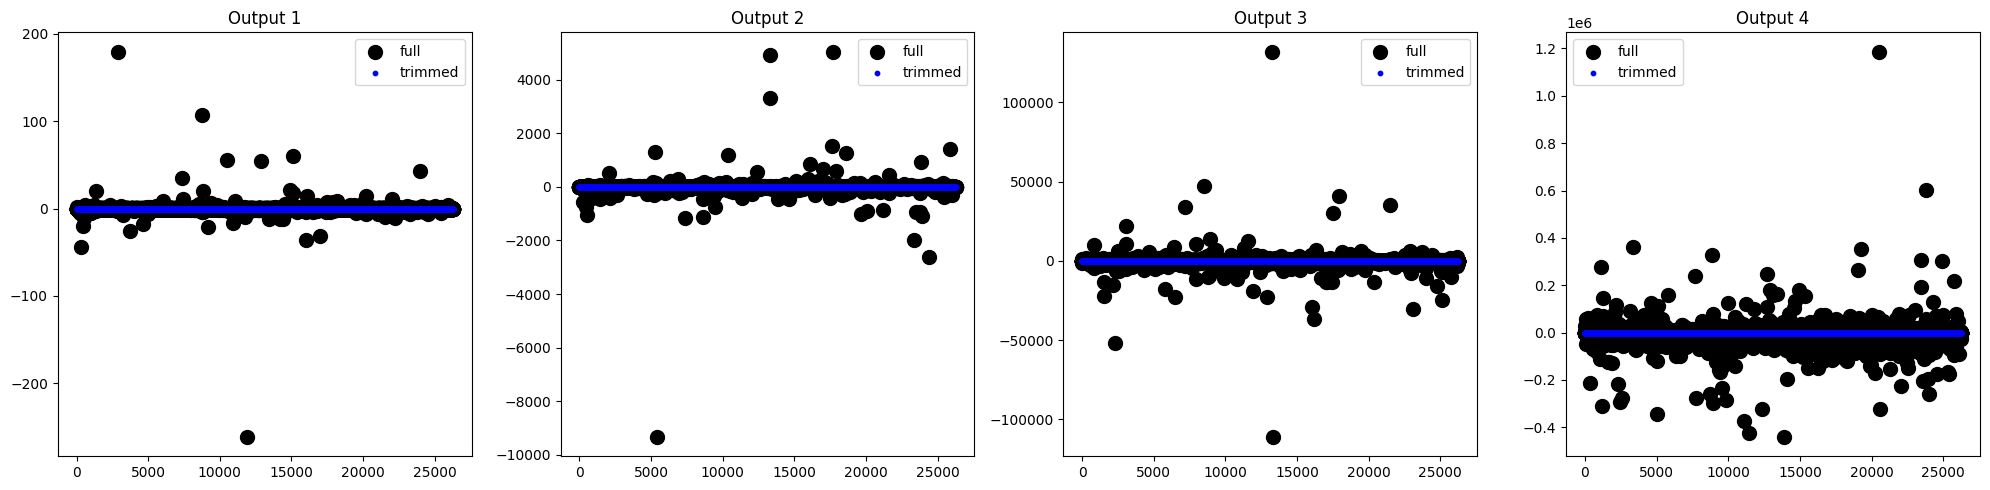

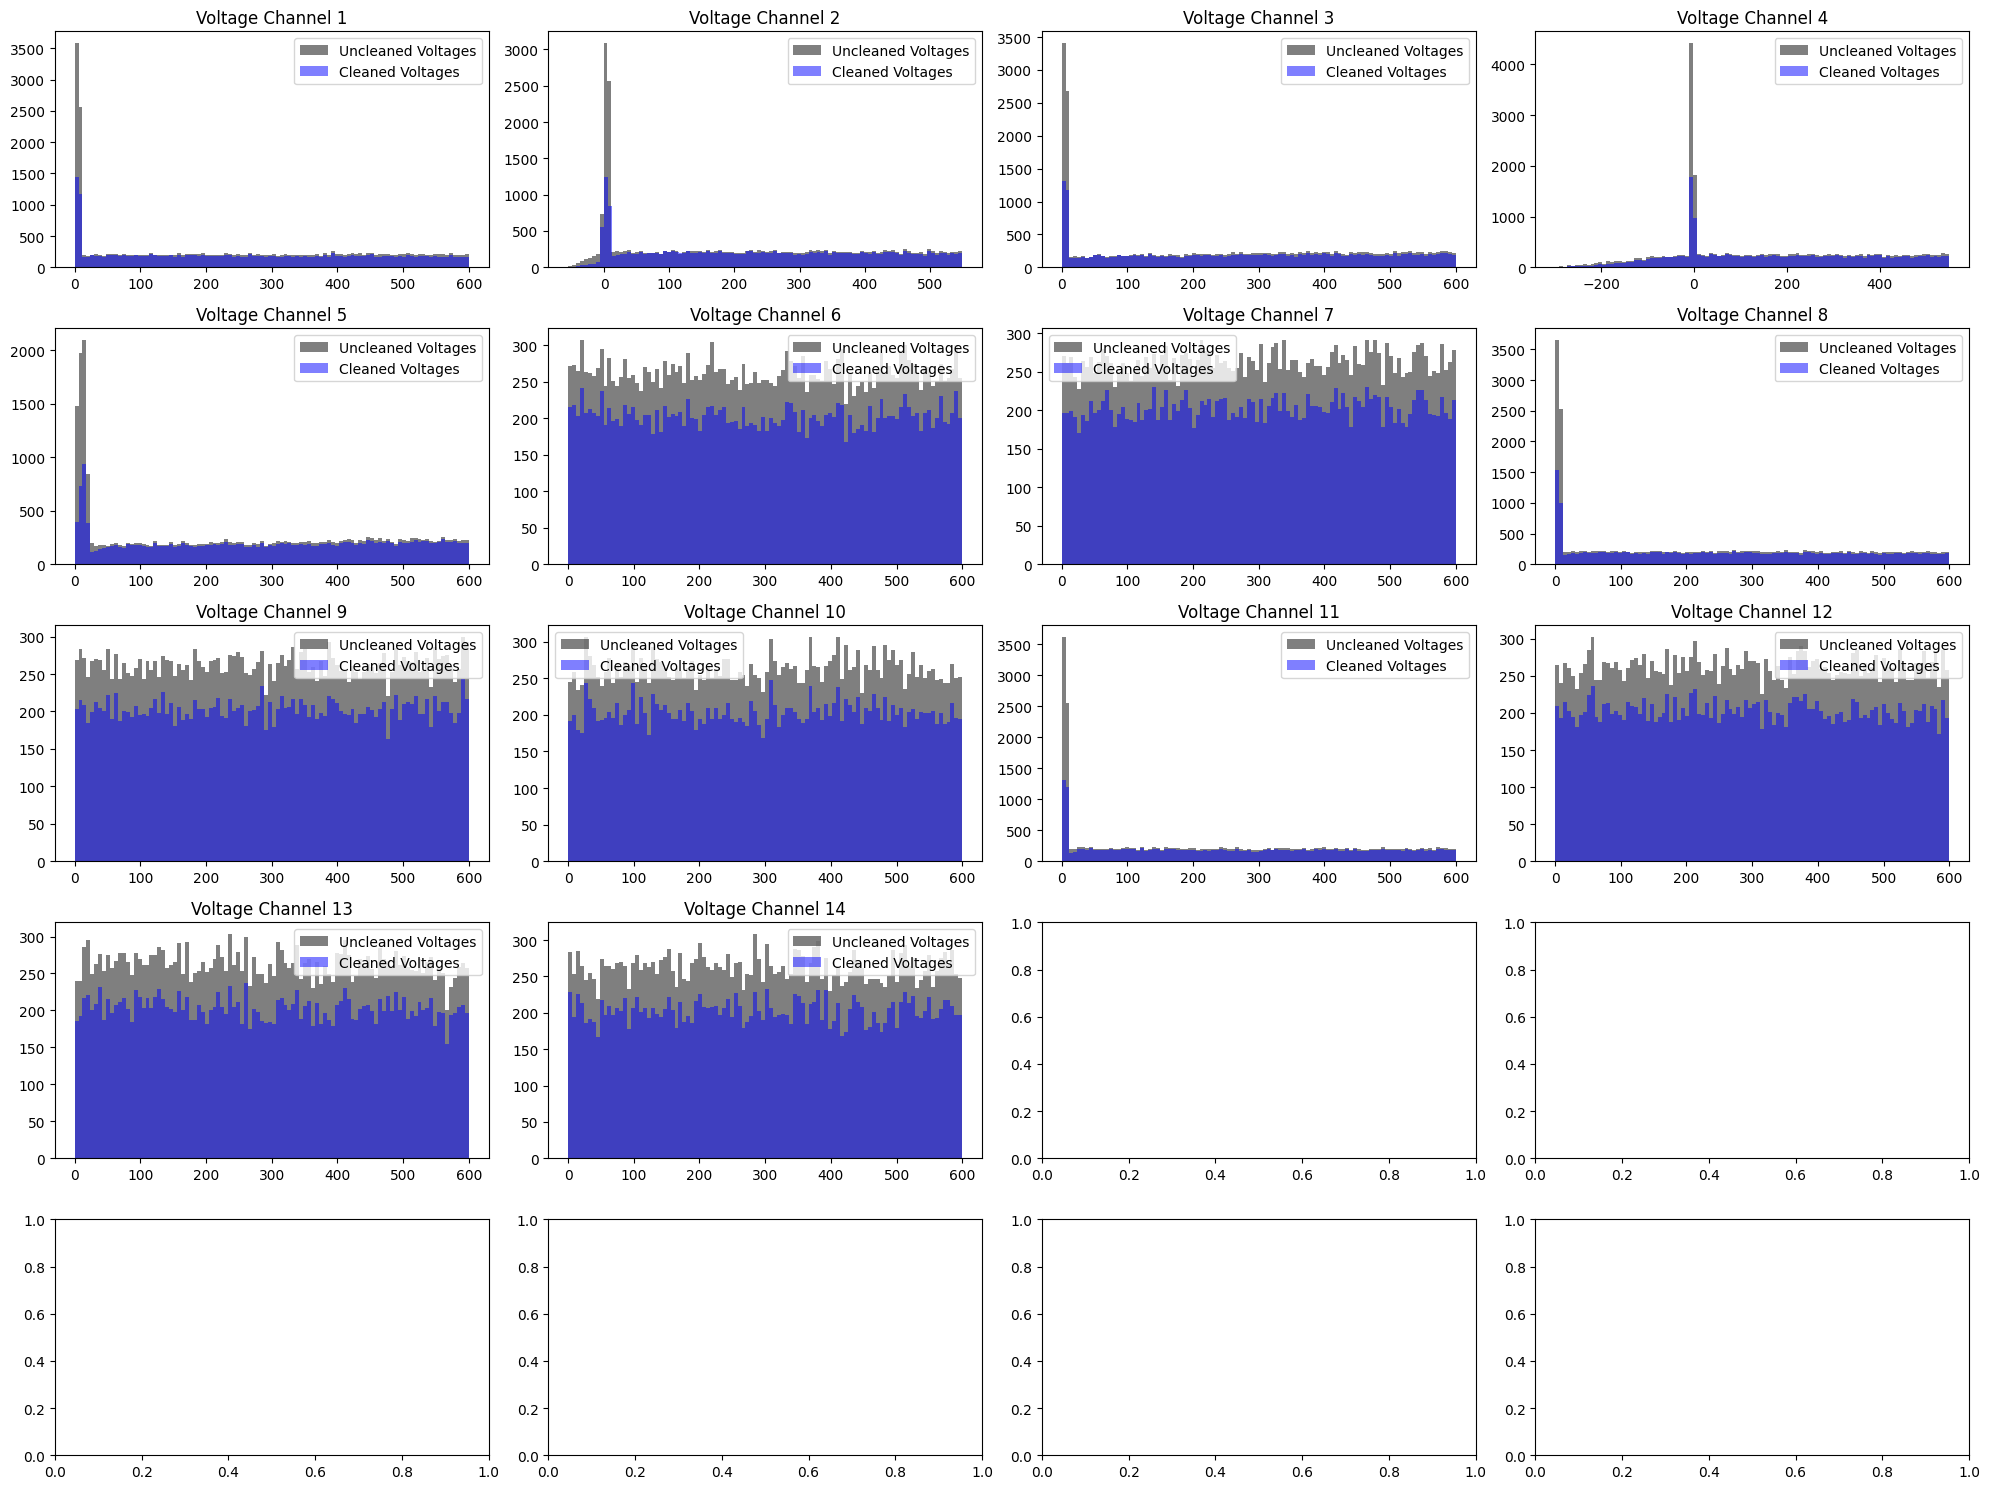

77.3% of data retained after cleaning


(-0.2, 0.2)

In [90]:
threshold = 20
_, ax, _, output_values, _, _ = trim_scatter(
    [
        "test_model_data.csv",
        "parallel_test_model_data.csv",
        "outlier_target_model_data.csv",
    ],
    output_values_start=22,
    output_values_end=25,
    trim_mode="iqr",
    trim_threshold=threshold,
    subplot_shape=(1, 4),
    figsize=(20, 5),
)
# ax[0].set_xlim(0, 100)
ax[0].set_ylim(-0.2, 0.2)
ax[1].set_ylim(-50, 50)
ax[2].set_ylim(-1000, 1000)
ax[3].set_ylim(-1500, 1500)


fig, ax, voltages_unclean, output_values_unclean, voltages, output_values = trim_hist(
    [
        "test_model_data.csv",
        "parallel_test_model_data.csv",
        "outlier_target_model_data.csv",
    ],
    output_values_start=22,
    output_values_end=25,
    trim_mode="iqr",
    trim_threshold=threshold,
    subplot_shape=(5, 4),
    hist_bins=100,
)

# ax[-1].scatter(np.arange(len(output_values)), output_values[:, 0])
ax[-3].set_xlim(-0.2, 0.2)

Using device: mps
Training model...
Epoch 0: Train Loss = 1.100412, Val Loss = 0.981980
Epoch 100: Train Loss = 0.774019, Val Loss = 0.790352
Epoch 200: Train Loss = 0.618029, Val Loss = 0.711578
Training completed. Best validation loss: 0.695950


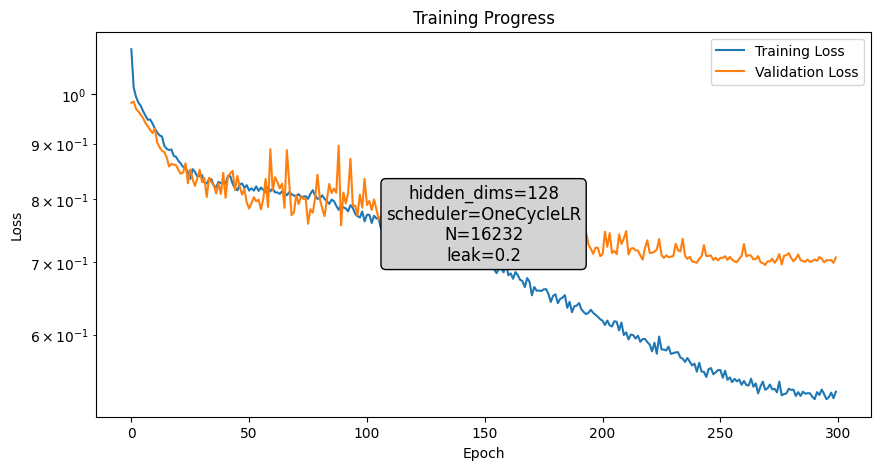

In [91]:
n_voltages = 14  # Number of voltage parameters
n_output_values = 4  # Number of output values (e.g., magnification, aberration, etc.)
raw_voltages, raw_output_values = load_data(
    [
        "parallel_test_model_data.csv",
        "test_model_data.csv",
        "outlier_target_model_data.csv",
    ],
    output_values_start=22,
    output_values_end=25,
)
voltages, outputs, outlier_voltages, outlier_outputs = trim_outliers(
    raw_voltages,
    raw_output_values,
    trim_threshold=threshold,
    trim_mode=trim_mode,
)
# Create and train model
predictor4 = ElectronOpticsPredictor(
    input_dim=n_voltages, output_dim=n_output_values, model=ResidualMLP, leak=0.2, hidden_dims=128
)
print("Training model...")
predictor4.train(
    voltages,
    outputs,
    epochs=EPOCH*2,
    verbose=True,
    checkpoint_name="best_model4.pt",
)


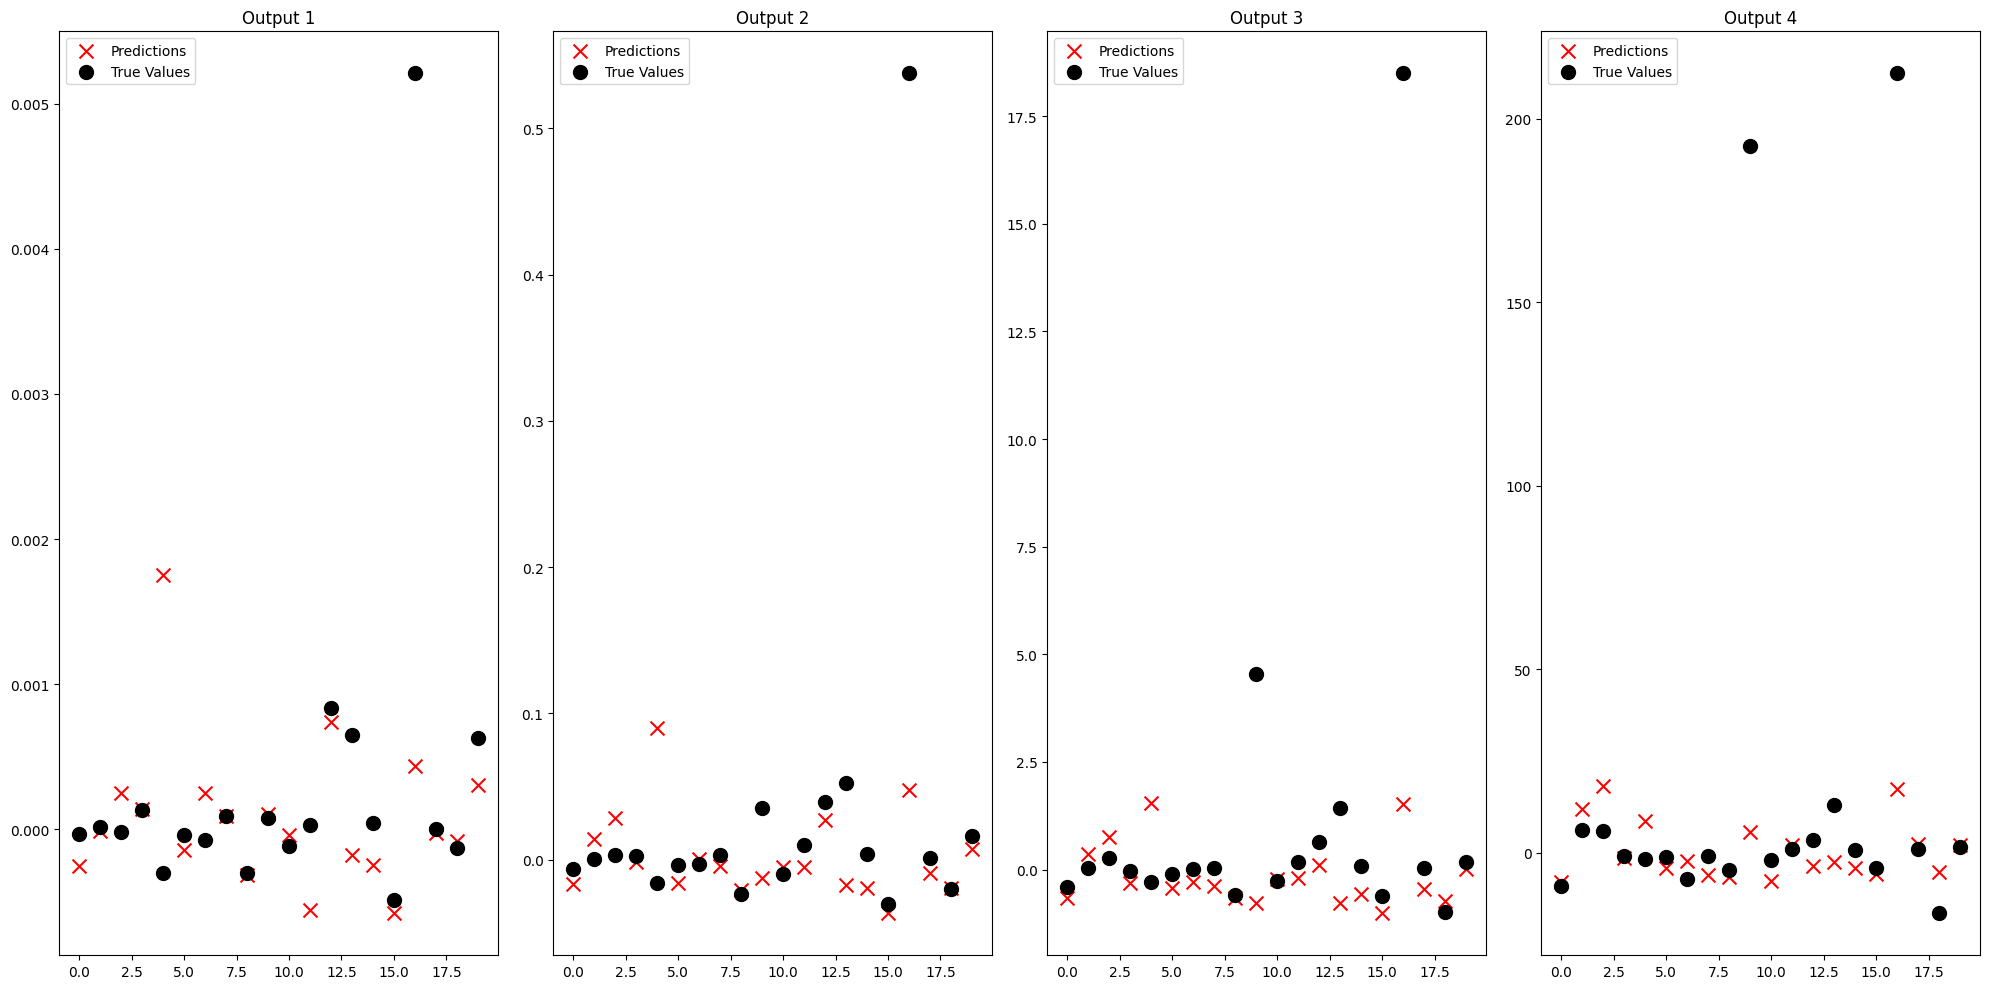

In [103]:
predictor4.model.to(device='mps')
_, _, all_predictions, all_true_values = plot_inference_comparison(
    predictor4,
    n_samples=20,
    subplot_shape=(1, 4),
)

/Users/larrywu/Documents/electron_optics
Restart 3, best objective: 151.39056396484375


(array([355.82568 , 457.21152 , 478.09653 , 268.6761  , 131.83177 ,
        311.44266 , 239.30002 , 249.72575 ,  96.05168 , 283.14734 ,
        210.1829  , 413.34903 ,  83.152824, 208.41792 ], dtype=float32),
 151.39056396484375)

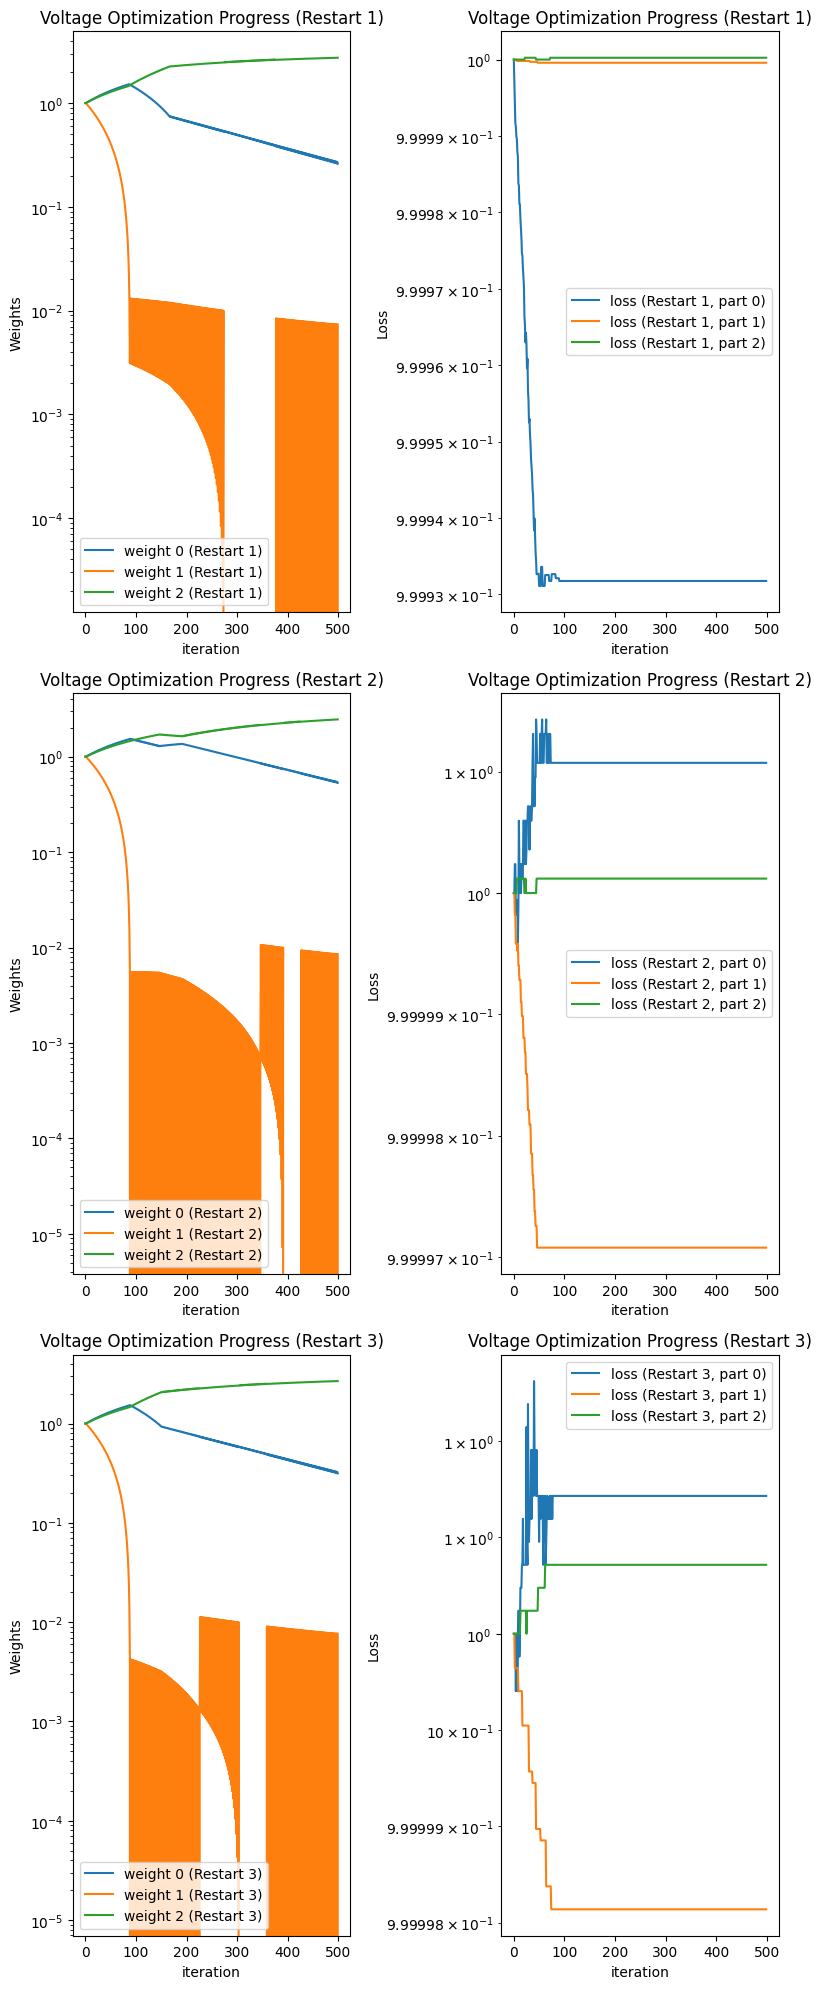

In [151]:
(best_voltages, best_values, best_objective), restart_results, _= optimize_voltages_gradnorm(
    [predictor1, predictor2, predictor3, predictor4], metric_split, random_restarts=3, n_iterations=500, learning_rate=1e-5, learning_rate_weights=5e-6, voltage_bounds=[0, 600], hyperparameters={'strength': 1e-5, 'min': 0, 'max': 600, 's': 1E10, 'alpha': 1.5}
)


best_voltages, best_objective



In [164]:
(best_voltages, best_values, best_objective)= optimize_voltages(
    [predictor1, predictor2, predictor3, predictor4], metric, random_restarts=3, n_iterations=200, learning_rate=1e0, voltage_bounds=[0, 600], hyperparameters={'strength': 0, 'min': 0, 'max': 600, 's': 1E10, 'alpha': 0.12},device='mps',clamp=True
)


best_voltages, best_objective



AttributeError: 'int' object has no attribute 'item'